# Final XGBoost Forecasting Notebook

**Purpose:** Train the final selected XGBoost model using the complete historical dataset and generate Malaysia CO₂ emission forecasts for 2023–2030.

This notebook follows the same structure as the training/testing notebooks:

1. Mount Drive and import libraries  
2. Load the final model-ready dataset  
3. Train the final selected XGBoost driver-based model  
4. Save the final trained model and feature columns  
5. Generate BAU and LCT scenario forecasts

In [1]:
# =========================================================
# 1. INSTALL / IMPORT LIBRARIES
# =========================================================
!pip install -q xgboost

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from google.colab import drive

In [2]:
# =========================================================
# 2. MOUNT GOOGLE DRIVE
# =========================================================
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =========================================================
# 3. DEFINE PROJECT PATHS
# =========================================================
project_dir = "/content/drive/MyDrive/FYP_2026"

data_path = os.path.join(project_dir, "DATA/FINAL_DATASETS/READY_FOR_TRAINING.csv")

model_dir = os.path.join(project_dir, "MODELS")
forecast_dir = os.path.join(project_dir, "RESULTS/FORECASTS/XGBOOST")
scenario_dir = os.path.join(project_dir, "RESULTS/SCENARIO/XGBOOST")
visualization_dir = os.path.join(project_dir, "RESULTS/VISUALIZATIONS/XGBOOST")

for folder in [model_dir, forecast_dir, scenario_dir, visualization_dir]:
    os.makedirs(folder, exist_ok=True)

print("Data path        :", data_path)
print("Model dir        :", model_dir)
print("Forecast dir     :", forecast_dir)
print("Scenario dir     :", scenario_dir)
print("Visualization dir:", visualization_dir)

Data path        : /content/drive/MyDrive/FYP_2026/DATA/FINAL_DATASETS/READY_FOR_TRAINING.csv
Model dir        : /content/drive/MyDrive/FYP_2026/MODELS
Forecast dir     : /content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/XGBOOST
Scenario dir     : /content/drive/MyDrive/FYP_2026/RESULTS/SCENARIO/XGBOOST
Visualization dir: /content/drive/MyDrive/FYP_2026/RESULTS/VISUALIZATIONS/XGBOOST


## Load Final Modelling Dataset

The notebook uses `READY_FOR_TRAINING.csv`, which contains the complete model-ready multi-country dataset with transformed variables and lag features.

In [4]:
# =========================================================
# 4. LOAD FINAL MODELLING DATASET
# =========================================================
df = pd.read_csv(data_path)
df = df.sort_values(["Country Code", "Year"]).reset_index(drop=True)

print("First year:", df["Year"].min())
print("Last year :", df["Year"].max())
print("Total rows:", len(df))

display(df.head())

First year: 1992
Last year : 2022
Total rows: 775


,Country Code,Year,GDP,Population,Energy_Use,CO2,Log_GDP,Log_Population,Log_Energy_Use,Log_CO2,Log_CO2_Lag1,Log_GDP_Lag1,Log_Energy_Lag1,Log_Pop_Lag1,Log_CO2_Lag2
0,ARG,1992,3.131202e+11,33693527.0,1407.276754,121514.170,26.469853,17.332816,7.250122,11.707794,11.676132,26.393473,7.234454,17.318973,11.627943
1,ARG,1993,3.388180e+11,34152717.0,1432.607503,118020.980,26.548729,17.346353,7.267949,11.678626,11.707794,26.469853,7.250122,17.332816,11.676132
2,ARG,1994,3.585921e+11,34613491.0,1530.527608,118506.770,26.605451,17.359754,7.334021,11.682734,11.678626,26.548729,7.267949,17.346353,11.707794
3,ARG,1995,3.483894e+11,35070020.0,1507.198475,125415.496,26.576587,17.372857,7.318671,11.739395,11.682734,26.605451,7.334021,17.359754,11.678626
4,ARG,1996,3.676438e+11,35513793.0,1534.091776,131445.544,26.630380,17.385432,7.336345,11.786356,11.739395,26.576587,7.318671,17.372857,11.682734


In [5]:
# =========================================================
# 5. ENCODE COUNTRY ID
# =========================================================
encoder = LabelEncoder()
df["Country_ID"] = encoder.fit_transform(df["Country Code"])

country_mapping = df[["Country Code", "Country_ID"]].drop_duplicates().sort_values("Country Code")

print("Country encoding preview:")
display(country_mapping.head())

Country encoding preview:


,Country Code,Country_ID
0,ARG,0
31,BGD,1
62,BRA,2
93,CHL,3
124,CHN,4


## Train Final Selected XGBoost Model

The training/testing notebooks are used for model evaluation and model selection.  
This notebook refits the selected final XGBoost driver-based model using all available historical data up to 2022 before generating future scenario forecasts.

In [6]:
# =========================================================
# 6. DEFINE FINAL FEATURES AND TARGET
# =========================================================
features = [
    "Country_ID",
    "Year",
    "Log_CO2_Lag1",
    "Log_CO2_Lag2",
    "Log_GDP_Lag1",
    "Log_Energy_Lag1",
    "Log_Pop_Lag1"
]

target = "Log_CO2"

train_df = df[df["Year"] <= 2022].copy()

X_train = train_df[features]
y_train = train_df[target]

print("Training period:", train_df["Year"].min(), "-", train_df["Year"].max())
print("Training rows  :", len(train_df))
print("Features used  :", features)

Training period: 1992 - 2022
Training rows  : 775
Features used  : ['Country_ID', 'Year', 'Log_CO2_Lag1', 'Log_CO2_Lag2', 'Log_GDP_Lag1', 'Log_Energy_Lag1', 'Log_Pop_Lag1']


In [7]:
# =========================================================
# 7. TRAIN FINAL XGBOOST MODEL
# =========================================================
final_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

final_model.fit(X_train, y_train)

print("Final XGBoost model trained successfully.")

Final XGBoost model trained successfully.


In [8]:
# =========================================================
# 8. SAVE FINAL MODEL AND FEATURE COLUMNS
# =========================================================
model_path = os.path.join(model_dir, "final_xgb_model.pkl")
feature_columns_path = os.path.join(model_dir, "feature_columns.pkl")
country_encoder_path = os.path.join(model_dir, "country_encoder.pkl")

joblib.dump(final_model, model_path)
joblib.dump(features, feature_columns_path)
joblib.dump(encoder, country_encoder_path)

print("Final model saved to        :", model_path)
print("Feature columns saved to    :", feature_columns_path)
print("Country encoder saved to    :", country_encoder_path)

Final model saved to        : /content/drive/MyDrive/FYP_2026/MODELS/final_xgb_model.pkl
Feature columns saved to    : /content/drive/MyDrive/FYP_2026/MODELS/feature_columns.pkl
Country encoder saved to    : /content/drive/MyDrive/FYP_2026/MODELS/country_encoder.pkl


## Prepare Malaysia Data

Malaysia's 2022 observation is used as the last known historical input for recursive forecasting.

In [9]:
# =========================================================
# 9. EXTRACT MALAYSIA DATA AND LAST KNOWN OBSERVATION
# =========================================================
df_mys = df[df["Country Code"] == "MYS"].copy()
df_mys = df_mys.sort_values("Year").reset_index(drop=True)

last_row = df_mys[df_mys["Year"] == 2022].iloc[0]

print("Malaysia historical range:", df_mys["Year"].min(), "-", df_mys["Year"].max())
print("Last known Malaysia row:")
display(last_row)

Malaysia historical range: 1992 - 2022
Last known Malaysia row:


,30
Country Code,MYS
Year,2022
GDP,388299855024.741943
Population,34695493.0
Energy_Use,2867.096519
CO2,281883.8
Log_GDP,26.685044
Log_Population,17.36212
Log_Energy_Use,7.961404
Log_CO2,12.549254


## Generate Business-as-Usual (BAU) Inputs

BAU assumes GDP, population and energy use continue according to recent historical growth patterns.

In [10]:
# =========================================================
# 10. DERIVE BAU GROWTH RATES FROM MALAYSIA HISTORICAL DATA
# =========================================================
df_mys["GDP_growth"] = df_mys["GDP"].pct_change()
df_mys["Pop_growth"] = df_mys["Population"].pct_change()
df_mys["Energy_growth"] = df_mys["Energy_Use"].pct_change()

# Use the available post-lag historical period as baseline.
recent = df_mys[df_mys["Year"] >= 1992].copy()

gdp_growth = recent["GDP_growth"].median()
pop_growth = recent["Pop_growth"].median()
energy_growth = recent["Energy_growth"].median()

# Small reinforcement to avoid overly flat projections.
gdp_growth = gdp_growth * 1.05
energy_growth = energy_growth * 1.03

# Safety fallback.
gdp_growth = 0.0 if pd.isna(gdp_growth) else gdp_growth
pop_growth = 0.0 if pd.isna(pop_growth) else pop_growth
energy_growth = 0.0 if pd.isna(energy_growth) else energy_growth

print("Historical median growth rates used for BAU:")
print(f"GDP growth   : {gdp_growth:.6f}")
print(f"Population   : {pop_growth:.6f}")
print(f"Energy growth: {energy_growth:.6f}")

Historical median growth rates used for BAU:
GDP growth   : 0.058056
Population   : 0.021574
Energy growth: 0.022488


In [11]:
# =========================================================
# 11. GENERATE BAU INPUTS (2023–2030)
# =========================================================
future_years = list(range(2023, 2031))

bau_rows = []

gdp_prev = last_row["GDP"]
pop_prev = last_row["Population"]
energy_prev = last_row["Energy_Use"]

for year in future_years:
    gdp_curr = gdp_prev * (1 + gdp_growth)
    pop_curr = pop_prev * (1 + pop_growth)
    energy_curr = energy_prev * (1 + energy_growth)

    bau_rows.append({
        "Year": year,
        "GDP": gdp_curr,
        "Population": pop_curr,
        "Energy_Use": energy_curr
    })

    gdp_prev = gdp_curr
    pop_prev = pop_curr
    energy_prev = energy_curr

df_bau = pd.DataFrame(bau_rows)

print("BAU future inputs:")
display(df_bau)

BAU future inputs:


,Year,GDP,Population,Energy_Use
0,2023,4.108430e+11,3.544400e+07,2931.570888
1,2024,4.346950e+11,3.620865e+07,2997.495136
2,2025,4.599316e+11,3.698981e+07,3064.901868
3,2026,4.866335e+11,3.778781e+07,3133.824422
4,2027,5.148855e+11,3.860303e+07,3204.296884
5,2028,5.447777e+11,3.943583e+07,3276.354109
6,2029,5.764054e+11,4.028661e+07,3350.031734
7,2030,6.098692e+11,4.115573e+07,3425.366198


## Recursive Forecasting Function

The recursive function updates lagged CO₂ values year-by-year so that each forecast becomes part of the next year's input.

In [12]:
# =========================================================
# 12. RECURSIVE FORECAST FUNCTION
# =========================================================
def recursive_forecast(model, future_df, last_known_row, feature_columns, smoothing_alpha=0.7):
    preds = []

    co2_lag1 = last_known_row["Log_CO2"]
    co2_lag2 = last_known_row["Log_CO2_Lag1"]
    country_id = last_known_row["Country_ID"]

    for i, row in future_df.iterrows():
        if i == 0:
            gdp_lag1 = np.log1p(last_known_row["GDP"])
            energy_lag1 = np.log1p(last_known_row["Energy_Use"])
            pop_lag1 = np.log1p(last_known_row["Population"])
        else:
            prev = future_df.iloc[i - 1]
            gdp_lag1 = np.log1p(prev["GDP"])
            energy_lag1 = np.log1p(prev["Energy_Use"])
            pop_lag1 = np.log1p(prev["Population"])

        X_future = pd.DataFrame([{
            "Country_ID": country_id,
            "Year": row["Year"],
            "Log_CO2_Lag1": co2_lag1,
            "Log_CO2_Lag2": co2_lag2,
            "Log_GDP_Lag1": gdp_lag1,
            "Log_Energy_Lag1": energy_lag1,
            "Log_Pop_Lag1": pop_lag1
        }])

        X_future = X_future[feature_columns]

        pred_log_raw = model.predict(X_future)[0]

        # Light smoothing to reduce recursive instability.
        pred_log = smoothing_alpha * pred_log_raw + (1 - smoothing_alpha) * co2_lag1
        pred_co2 = np.expm1(pred_log)

        preds.append({
            "Year": int(row["Year"]),
            "Pred_Log_CO2": pred_log,
            "Pred_CO2": pred_co2
        })

        co2_lag2 = co2_lag1
        co2_lag1 = pred_log

    return pd.DataFrame(preds)

In [13]:
# =========================================================
# 13. FORECAST BAU (2023–2030)
# =========================================================
forecast_bau = recursive_forecast(
    final_model,
    df_bau,
    last_row,
    features,
    smoothing_alpha=0.7
)

print("BAU forecast:")
display(forecast_bau)

BAU forecast:


,Year,Pred_Log_CO2,Pred_CO2
0,2023,12.524265,274927.182004
1,2024,12.516769,272873.869417
2,2025,12.514520,272260.871242
3,2026,12.513845,272077.240459
4,2027,12.516254,272733.399645
5,2028,12.518215,273268.879191
6,2029,12.518804,273429.727974
7,2030,12.518980,273478.001068


## Generate Low-Carbon Transition (LCT) Inputs

LCT uses the same GDP and population assumptions as BAU, while energy use is reduced using a compound annual efficiency factor.

In [14]:
# =========================================================
# 14. GENERATE LCT INPUTS FROM BAU
#     EnergyUse_t^LCT = EnergyUse_t^BAU * (1 - r)^(t - 2023)
# =========================================================
r = 0.05  # assumed annual efficiency improvement rate

lct_rows = []

for _, row in df_bau.iterrows():
    year = row["Year"]

    energy_lct = row["Energy_Use"] * ((1 - r) ** (year - 2023))

    lct_rows.append({
        "Year": year,
        "GDP": row["GDP"],
        "Population": row["Population"],
        "Energy_Use": energy_lct
    })

df_lct = pd.DataFrame(lct_rows)

print("LCT future inputs:")
display(df_lct)

LCT future inputs:


,Year,GDP,Population,Energy_Use
0,2023.0,4.108430e+11,3.544400e+07,2931.570888
1,2024.0,4.346950e+11,3.620865e+07,2847.620379
2,2025.0,4.599316e+11,3.698981e+07,2766.073936
3,2026.0,4.866335e+11,3.778781e+07,2686.862713
4,2027.0,5.148855e+11,3.860303e+07,2609.919839
5,2028.0,5.447777e+11,3.943583e+07,2535.180354
6,2029.0,5.764054e+11,4.028661e+07,2462.581161
7,2030.0,6.098692e+11,4.115573e+07,2392.060969


In [15]:
# =========================================================
# 15. FORECAST LCT (2023–2030)
# =========================================================
forecast_lct = recursive_forecast(
    final_model,
    df_lct,
    last_row,
    features,
    smoothing_alpha=0.7
)

print("LCT forecast:")
display(forecast_lct)

LCT forecast:


,Year,Pred_Log_CO2,Pred_CO2
0,2023,12.524265,274927.182004
1,2024,12.516769,272873.869417
2,2025,12.514520,272260.871242
3,2026,12.513845,272077.240459
4,2027,12.513643,272022.175379
5,2028,12.514821,272342.834923
6,2029,12.514682,272305.072784
7,2030,12.514640,272293.745163


In [16]:
# =========================================================
# 16. COMPARE BAU VS LCT
# =========================================================
forecast_compare = forecast_bau.merge(
    forecast_lct,
    on="Year",
    suffixes=("_BAU", "_LCT")
)

forecast_compare["Gap"] = (
    forecast_compare["Pred_CO2_BAU"] - forecast_compare["Pred_CO2_LCT"]
)

print("Scenario comparison:")
display(forecast_compare)

Scenario comparison:


,Year,Pred_Log_CO2_BAU,Pred_CO2_BAU,Pred_Log_CO2_LCT,Pred_CO2_LCT,Gap
0,2023,12.524265,274927.182004,12.524265,274927.182004,0.000000
1,2024,12.516769,272873.869417,12.516769,272873.869417,0.000000
2,2025,12.514520,272260.871242,12.514520,272260.871242,0.000000
3,2026,12.513845,272077.240459,12.513845,272077.240459,0.000000
4,2027,12.516254,272733.399645,12.513643,272022.175379,711.224267
5,2028,12.518215,273268.879191,12.514821,272342.834923,926.044268
6,2029,12.518804,273429.727974,12.514682,272305.072784,1124.655190
7,2030,12.518980,273478.001068,12.514640,272293.745163,1184.255905


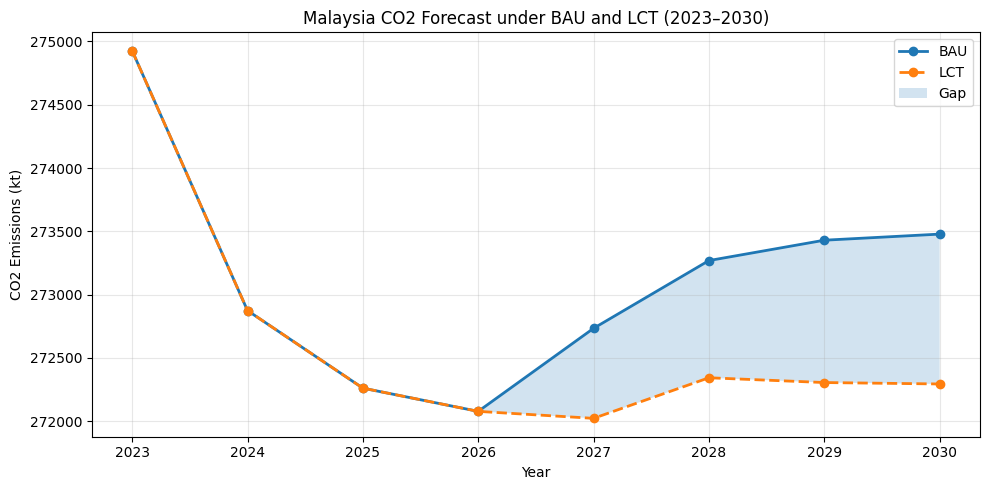

BAU vs LCT plot saved to: /content/drive/MyDrive/FYP_2026/RESULTS/VISUALIZATIONS/XGBOOST/XGB_BAU_LCT_FORECAST_2023_2030_plot.png


In [17]:
# =========================================================
# 17. PLOT BAU VS LCT
# =========================================================
bau_lct_plot_path = os.path.join(
    visualization_dir,
    "XGB_BAU_LCT_FORECAST_2023_2030_plot.png"
)

plt.figure(figsize=(10, 5))

plt.plot(
    forecast_compare["Year"],
    forecast_compare["Pred_CO2_BAU"],
    marker="o",
    linewidth=2,
    label="BAU"
)

plt.plot(
    forecast_compare["Year"],
    forecast_compare["Pred_CO2_LCT"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="LCT"
)

plt.fill_between(
    forecast_compare["Year"],
    forecast_compare["Pred_CO2_BAU"],
    forecast_compare["Pred_CO2_LCT"],
    alpha=0.2,
    label="Gap"
)

plt.title("Malaysia CO2 Forecast under BAU and LCT (2023–2030)")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions (kt)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(bau_lct_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("BAU vs LCT plot saved to:", bau_lct_plot_path)

In [18]:
# =========================================================
# 18. SAVE BAU AND LCT OUTPUTS
# =========================================================
bau_path = os.path.join(scenario_dir, "XGB_BAU_FORECAST_2023_2030.csv")
lct_path = os.path.join(scenario_dir, "XGB_LCT_FORECAST_2023_2030.csv")
comparison_path = os.path.join(scenario_dir, "XGB_BAU_LCT_COMPARISON_2023_2030.csv")

forecast_bau.to_csv(bau_path, index=False)
forecast_lct.to_csv(lct_path, index=False)
forecast_compare.to_csv(comparison_path, index=False)

print("BAU forecast saved to       :", bau_path)
print("LCT forecast saved to       :", lct_path)
print("BAU-LCT comparison saved to :", comparison_path)

BAU forecast saved to       : /content/drive/MyDrive/FYP_2026/RESULTS/SCENARIO/XGBOOST/XGB_BAU_FORECAST_2023_2030.csv
LCT forecast saved to       : /content/drive/MyDrive/FYP_2026/RESULTS/SCENARIO/XGBOOST/XGB_LCT_FORECAST_2023_2030.csv
BAU-LCT comparison saved to : /content/drive/MyDrive/FYP_2026/RESULTS/SCENARIO/XGBOOST/XGB_BAU_LCT_COMPARISON_2023_2030.csv


In [24]:
# =========================================================
# 19. EXPORT BAU AND LCT FORECASTS FOR POWER BI
# =========================================================
xgb_bau_export = forecast_bau[["Year", "Pred_CO2"]].copy()
xgb_bau_export["Model"] = "XGBoost"
xgb_bau_export["Scenario"] = "BAU"
xgb_bau_export = xgb_bau_export.rename(columns={"Pred_CO2": "Forecast_CO2"})

xgb_lct_export = forecast_lct[["Year", "Pred_CO2"]].copy()
xgb_lct_export["Model"] = "XGBoost"
xgb_lct_export["Scenario"] = "LCT"
xgb_lct_export = xgb_lct_export.rename(columns={"Pred_CO2": "Forecast_CO2"})

forecast_powerbi = pd.concat(
    [xgb_bau_export, xgb_lct_export],
    ignore_index=True
)

powerbi_path = os.path.join(forecast_dir, "XGB_FORECAST_POWERBI_2023_2030.csv")
forecast_powerbi.to_csv(powerbi_path, index=False)

print("Power BI forecast export saved to:", powerbi_path)
display(forecast_powerbi.head())

Power BI forecast export saved to: /content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/XGBOOST/XGB_FORECAST_POWERBI_2023_2030.csv


,Year,Forecast_CO2,Model,Scenario
0,2023,274927.182004,XGBoost,BAU
1,2024,272873.869417,XGBoost,BAU
2,2025,272260.871242,XGBoost,BAU
3,2026,272077.240459,XGBoost,BAU
4,2027,272733.399645,XGBoost,BAU


In [19]:
import os
import pandas as pd

arima_folder = "/content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/ARIMA"

print(os.listdir(arima_folder))

['ARIMA_HOLDOUT_predictions.csv', 'ARIMA_ROLLING_predictions.csv', 'ARIMA_FORECAST_2023_2030.csv']


In [20]:
# =========================================================
# 19. LOAD ARIMA FORECAST FOR COMPARISON
# =========================================================

import pandas as pd

arima_path = "/content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/ARIMA/ARIMA_FORECAST_2023_2030.csv"

arima_df = pd.read_csv(arima_path)

if "Forecast_CO2" in arima_df.columns:
    arima_df = arima_df.rename(columns={"Forecast_CO2": "ARIMA_CO2"})

display(arima_df.head())

,Year,ARIMA_CO2
0,2023,294873.735965
1,2024,308462.281839
2,2025,322677.023118
3,2026,337546.816507
4,2027,353101.848507


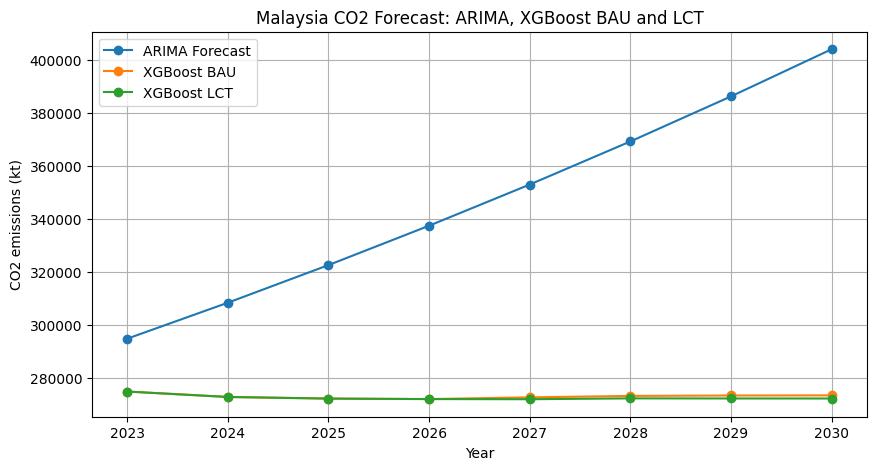

Saved plot to: /content/drive/MyDrive/FYP_2026/RESULTS/VISUALIZATIONS/XGBOOST/ARIMA_XGB_BAU_LCT_FORECAST_2023_2030_plot.png


In [23]:
# =========================================================
# PLOT ARIMA + XGBOOST BAU/LCT
# =========================================================

plt.figure(figsize=(10, 5))

plt.plot(
    arima_df["Year"],
    arima_df["ARIMA_CO2"],
    marker="o",
    label="ARIMA Forecast"
)

plt.plot(
    forecast_bau["Year"],
    forecast_bau["Pred_CO2"],
    marker="o",
    label="XGBoost BAU"
)

plt.plot(
    forecast_lct["Year"],
    forecast_lct["Pred_CO2"],
    marker="o",
    label="XGBoost LCT"
)

plt.title("Malaysia CO2 Forecast: ARIMA, XGBoost BAU and LCT")
plt.xlabel("Year")
plt.ylabel("CO2 emissions (kt)")
plt.legend()
plt.grid(True)

plot_path = os.path.join(
    visualization_dir,
    "ARIMA_XGB_BAU_LCT_FORECAST_2023_2030_plot.png"
)

plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot to:", plot_path)